# Importing libraries

In [1]:
import requests
import chessdotcom
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk
import seaborn as sb
from chessdotcom import get_leaderboards
import re
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
import chess.pgn
import os
import math
import statsmodels.api as sm
from scipy.stats import linregress
from linearmodels.panel import PanelOLS
import statsmodels.api as smf
from linearmodels.panel.utility import AbsorbingEffectError
from linearmodels.panel import RandomEffects
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Import Data

In [2]:
df = pd.read_excel("DB.xlsx")
df = df[df['w_or_b']==1]
df_for_reg = df[df['last_game'] != 'first']
df_for_reg['k_PO'] = df_for_reg['k_p']-df_for_reg['k_opp'] 

C:\Users\itayt\AppData\Local\Temp\ipykernel_21488\2895583742.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_for_reg['k_PO'] = df_for_reg['k_p']-df_for_reg['k_opp']


In [3]:
import numpy as np
from scipy.optimize import curve_fit


X = np.array([
    -750,-700,-650,-600,-550,-500,-450,-400,-350,-300,
    -250,-200,-150,-100,-50,0,
    50,100,150,200,250,300,350,400,450,500,
    550,600,650,700,750
])

Y = np.array([
    0.115,0.167,0.183,0.171,0.199,
    0.272,0.213,0.227,0.311,0.304,
    0.322,0.366,0.390,0.418,0.499,
    0.528,0.577,0.639,0.668,0.688,
    0.724,0.756,0.773,0.801,0.778,
    0.837,0.837,0.800,0.828,0.882,0.882
])

def elo_white_adv(x, L, W):
    return 1 / (1 + 10 ** (-(x + W) / L))

params, _ = curve_fit(
    elo_white_adv,
    X,
    Y,
    p0=[800, 40]
)

L_opt, W_opt = params

print(f"L_opt = {L_opt:.2f}")
print(f"W_opt = {W_opt:.2f}")
print(f"P(X=0) = {1 / (1 + 10 ** (-W_opt / L_opt)):.3f}")

df = df.assign(
    ELO_Emp_A=lambda x: 1 / (1 + 10 ** (-(x['Elo_A'] - x['Elo_B'] + W_opt) / L_opt)),
    ELO_Emp_B=lambda x: 1 - (1 / (1 + 10 ** (-(x['Elo_A'] - x['Elo_B'] + W_opt) / L_opt)))
)




L_opt = 814.87
W_opt = 42.49
P(X=0) = 0.530


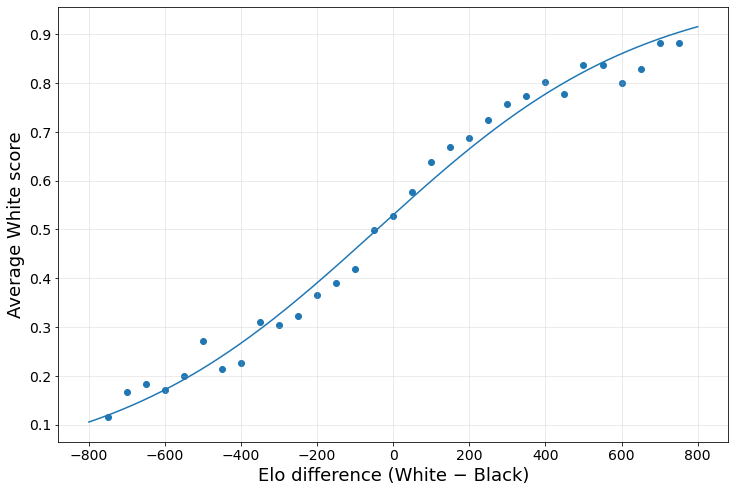

In [4]:

L_opt = 814.87
W_opt =42.49


def elo_white_adv(x, L, W):
    return 1 / (1 + 10 ** (-(x + W) / L))


X_fine = np.linspace(-800, 800, 500)
Y_fit = elo_white_adv(X_fine, L_opt, W_opt)

plt.figure(figsize=(12,8))
plt.scatter(X, Y)
plt.plot(X_fine, Y_fit)

plt.xlabel("Elo difference (White − Black)", fontsize=18)
plt.ylabel("Average White score", fontsize=18)
plt.tick_params(axis='both', labelsize=14)
plt.grid(alpha=0.3)


plt.savefig("elo_white_adv.png", dpi=300, bbox_inches='tight')

plt.show()


In [5]:
df['player_id'] = df['player'].astype('category').cat.codes
df['opp_id'] = df['Opp'].astype('category').cat.codes
df['event_id'] = df['Event'].astype('category').cat.codes

df_for_reg = df[df['last_game'] != 'first']
df_for_reg['k_PO'] = df_for_reg['k_p']-df_for_reg['k_opp'] 


C:\Users\itayt\AppData\Local\Temp\ipykernel_21488\3972648809.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_for_reg['k_PO'] = df_for_reg['k_p']-df_for_reg['k_opp']


# Table 4: OLS Regressions for Game Outcome

## Reg (1)

In [6]:
import pandas as pd
import statsmodels.api as sm


df = df_for_reg[df_for_reg['w_or_b'] == 1].copy()


df['k_PO'] = pd.to_numeric(df['k_PO'], errors='coerce')
df['Y_Result'] = pd.to_numeric(df['Y_Result'], errors='coerce')


df = df[['k_PO', 'Y_Result', 'player_id', 'opp_id']].dropna()


df['player_id'] = df['player_id'].astype(int)
df['opp_id'] = df['opp_id'].astype(int)

X = df[['k_PO']]
X = sm.add_constant(X)

Y = df['Y_Result']

model = sm.OLS(Y, X)

# ===== 6. two-way clustering (player + opponent)
groups = df[['player_id', 'opp_id']]

result_cluster_2way = model.fit(
    cov_type='cluster',
    cov_kwds={'groups': groups}
)


print("\n========== OLS with Two-Way Clustering ==========")
print(result_cluster_2way.summary())


========== OLS with Two-Way Clustering ==========
                            OLS Regression Results                            
Dep. Variable:               Y_Result   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     198.6
Date:                Fri, 24 Apr 2026   Prob (F-statistic):           7.70e-43
Time:                        11:46:45   Log-Likelihood:                -14732.
No. Observations:               24809   AIC:                         2.947e+04
Df Residuals:                   24807   BIC:                         2.948e+04
Df Model:                           1                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c

## Reg (2) 

In [7]:
import pandas as pd
import statsmodels.api as sm


df = df_for_reg[df_for_reg['w_or_b'] == 1].copy()
df['k_PO'] = pd.to_numeric(df['k_PO'], errors='coerce')
df['Y_Result'] = pd.to_numeric(df['Y_Result'], errors='coerce')
df = df.dropna()

df['player_id'] = df['player_id'].astype(int)
df['opp_id'] = df['opp_id'].astype(int)

X = df[['k_PO','ELO_Emp_A']]
X = sm.add_constant(X)

Y = df['Y_Result']

model = sm.OLS(Y, X)

# ===== 6. two-way clustering (player + opponent)
groups = df[['player_id', 'opp_id']]

result_cluster_2way = model.fit(
    cov_type='cluster',
    cov_kwds={'groups': groups}
)

print("\n========== OLS with Two-Way Clustering ==========")
print(result_cluster_2way.summary())


========== OLS with Two-Way Clustering ==========
                            OLS Regression Results                            
Dep. Variable:               Y_Result   R-squared:                       0.121
Model:                            OLS   Adj. R-squared:                  0.121
Method:                 Least Squares   F-statistic:                     945.6
Date:                Fri, 24 Apr 2026   Prob (F-statistic):          1.41e-280
Time:                        11:46:45   Log-Likelihood:                -13252.
No. Observations:               24809   AIC:                         2.651e+04
Df Residuals:                   24806   BIC:                         2.653e+04
Df Model:                           2                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c

## Reg(3)

In [8]:
import statsmodels.formula.api as smf
# =========================
# 6. Fixed Effects: Tournament + Round FE
# =========================

model_fe = smf.ols(
    'Y_Result ~ k_PO + ELO_Emp_A + C(event_id) + C(round)',
    data=df
)

result_fe = model_fe.fit(
    cov_type='cluster',
    cov_kwds={'groups': df[['player_id', 'opp_id']]}
)

print("\n========== FE: Event + Round ==========")
print(result_fe.summary())



========== FE: Event + Round ==========
                            OLS Regression Results                            
Dep. Variable:               Y_Result   R-squared:                       0.123
Model:                            OLS   Adj. R-squared:                  0.122
Method:                 Least Squares   F-statistic:                     703.7
Date:                Fri, 24 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:46:45   Log-Likelihood:                -13220.
No. Observations:               24809   AIC:                         2.654e+04
Df Residuals:                   24761   BIC:                         2.693e+04
Df Model:                          47                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------

## Reg (4) 

In [9]:
import pandas as pd
import statsmodels.api as sm

# ===== 1. סינון ללבן + copy (מונע SettingWithCopyWarning)
df = df_for_reg[df_for_reg['w_or_b'] == 1].copy()

# ===== 2. המרות למספרים
df['k_PO'] = pd.to_numeric(df['k_PO'], errors='coerce')
df['Y_Result'] = pd.to_numeric(df['Y_Result'], errors='coerce')

# ===== 3. ניקוי נתונים (כולל עמודות cluster)
df = df.dropna()
df['player_id'] = df['player_id'].astype(int)
df['opp_id'] = df['opp_id'].astype(int)

X = df[['k_PO','Elo_prob']]
X = sm.add_constant(X)

Y = df['Y_Result']

model = sm.OLS(Y, X)

# ===== 6. two-way clustering (player + opponent)
groups = df[['player_id', 'opp_id']]

result_cluster_2way = model.fit(
    cov_type='cluster',
    cov_kwds={'groups': groups}
)
print("\n========== OLS with Two-Way Clustering ==========")
print(result_cluster_2way.summary())


========== OLS with Two-Way Clustering ==========
                            OLS Regression Results                            
Dep. Variable:               Y_Result   R-squared:                       0.123
Model:                            OLS   Adj. R-squared:                  0.123
Method:                 Least Squares   F-statistic:                     1094.
Date:                Fri, 24 Apr 2026   Prob (F-statistic):          1.39e-310
Time:                        11:46:46   Log-Likelihood:                -13221.
No. Observations:               24809   AIC:                         2.645e+04
Df Residuals:                   24806   BIC:                         2.647e+04
Df Model:                           2                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
c

## Reg (5)

In [10]:
import statsmodels.formula.api as smf
# =========================
# 6. Fixed Effects: Tournament + Round FE
# =========================

model_fe = smf.ols(
    'Y_Result ~ k_PO + Elo_prob + C(event_id) + C(round)',
    data=df
)

result_fe = model_fe.fit(
    cov_type='cluster',
    cov_kwds={'groups': df[['player_id', 'opp_id']]}
)

print("\n========== FE: Event + Round ==========")
print(result_fe.summary())



========== FE: Event + Round ==========
                            OLS Regression Results                            
Dep. Variable:               Y_Result   R-squared:                       0.126
Model:                            OLS   Adj. R-squared:                  0.124
Method:                 Least Squares   F-statistic:                     716.4
Date:                Fri, 24 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:46:46   Log-Likelihood:                -13188.
No. Observations:               24809   AIC:                         2.647e+04
Df Residuals:                   24761   BIC:                         2.686e+04
Df Model:                          47                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------

# Table 5 : OLS Regressions by Tournament Category

## ALL

In [11]:
import statsmodels.formula.api as smf
# =========================
# 6. Fixed Effects: Tournament + Round FE
# =========================

model_fe = smf.ols(
    'Y_Result ~ k_PO + ELO_Emp_A + C(event_id) + C(round)',
    data=df
)

result_fe = model_fe.fit(
    cov_type='cluster',
    cov_kwds={'groups': df[['player_id', 'opp_id']]}
)

print("\n========== FE: Event + Round ==========")
print(result_fe.summary())



========== FE: Event + Round ==========
                            OLS Regression Results                            
Dep. Variable:               Y_Result   R-squared:                       0.123
Model:                            OLS   Adj. R-squared:                  0.122
Method:                 Least Squares   F-statistic:                     703.7
Date:                Fri, 24 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:46:46   Log-Likelihood:                -13220.
No. Observations:               24809   AIC:                         2.654e+04
Df Residuals:                   24761   BIC:                         2.693e+04
Df Model:                          47                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------

## World Champ

In [12]:
df_top = df[df['Top_10_elo'] == 1].copy().reset_index(drop=True)

# =========================
# 6. Fixed Effects: Tournament and round FE
# =========================

model_fe = smf.ols(
    'Y_Result ~ k_PO + ELO_Emp_A + C(event_id) + C(round)',
    data=df_top
)

result_fe = model_fe.fit(
    cov_type='cluster',
    cov_kwds={'groups': df_top[['player_id', 'opp_id']]}
)

print("\n========== FE: Event + Round ==========")
print(result_fe.summary())



========== FE: Event + Round ==========
                            OLS Regression Results                            
Dep. Variable:               Y_Result   R-squared:                       0.100
Model:                            OLS   Adj. R-squared:                  0.098
Method:                 Least Squares   F-statistic:                     569.3
Date:                Fri, 24 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:46:47   Log-Likelihood:                -7287.7
No. Observations:               13817   AIC:                         1.464e+04
Df Residuals:                   13785   BIC:                         1.488e+04
Df Model:                          31                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------

## Fast Games

In [13]:
df_fast = df[df['FAST_T'] == 1].copy().reset_index(drop=True)


# =========================
# 6. Fixed Effects: Tournament and round FE
# =========================

model_fe = smf.ols(
    'Y_Result ~ k_PO + ELO_Emp_A + C(event_id) + C(round)',
    data=df_fast
)

result_fe = model_fe.fit(
    cov_type='cluster',
    cov_kwds={'groups': df_fast[['player_id', 'opp_id']]}
)

print("\n========== FE: Event + Round ==========")
print(result_fe.summary())



========== FE: Event + Round ==========
                            OLS Regression Results                            
Dep. Variable:               Y_Result   R-squared:                       0.111
Model:                            OLS   Adj. R-squared:                  0.109
Method:                 Least Squares   F-statistic:                     669.1
Date:                Fri, 24 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:46:47   Log-Likelihood:                -8753.4
No. Observations:               15561   AIC:                         1.757e+04
Df Residuals:                   15527   BIC:                         1.783e+04
Df Model:                          33                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------

## Regular Games

In [14]:
df_reg = df[df['FAST_T'] == 0].copy().reset_index(drop=True)


# =========================
# 6. Fixed Effects: Tournament and round FE
# =========================

model_fe = smf.ols(
    'Y_Result ~ k_PO + ELO_Emp_A + C(event_id) + C(round)',
    data=df_reg
)

result_fe = model_fe.fit(
    cov_type='cluster',
    cov_kwds={'groups': df_reg[['player_id', 'opp_id']]}
)

print("\n========== FE: Event + Round ==========")
print(result_fe.summary())



========== FE: Event + Round ==========
                            OLS Regression Results                            
Dep. Variable:               Y_Result   R-squared:                       0.148
Model:                            OLS   Adj. R-squared:                  0.145
Method:                 Least Squares   F-statistic:                     47.98
Date:                Fri, 24 Apr 2026   Prob (F-statistic):          1.26e-173
Time:                        11:46:47   Log-Likelihood:                -4417.8
No. Observations:                9248   AIC:                             8890.
Df Residuals:                    9221   BIC:                             9082.
Df Model:                          26                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------

## Women’s Tourn.

In [15]:
df_women = df[df['women'] == 1].copy().reset_index(drop=True)


# =========================
# 6. Fixed Effects: Tournament and round FE
# =========================

model_fe = smf.ols(
    'Y_Result ~ k_PO + ELO_Emp_A + C(event_id) + C(round)',
    data=df_women
)

result_fe = model_fe.fit(
    cov_type='cluster',
    cov_kwds={'groups': df_women[['player_id', 'opp_id']]}
)

print("\n========== FE: Event + Round ==========")
print(result_fe.summary())



========== FE: Event + Round ==========
                            OLS Regression Results                            
Dep. Variable:               Y_Result   R-squared:                       0.103
Model:                            OLS   Adj. R-squared:                  0.099
Method:                 Least Squares   F-statistic:                     20.63
Date:                Fri, 24 Apr 2026   Prob (F-statistic):           2.37e-60
Time:                        11:46:47   Log-Likelihood:                -3556.3
No. Observations:                6209   AIC:                             7173.
Df Residuals:                    6179   BIC:                             7375.
Df Model:                          29                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------

# <span class="girk">Appendix</span>

## Table 6: Separating the Effects of Previous Wins and Losses

### Reg (1)

In [16]:
import statsmodels.formula.api as smf
# =========================
# 6. Fixed Effects: Tournament + Round FE
# =========================

model_fe = smf.ols(
    'Y_Result ~ W_W + W_L + B_W + B_L + ELO_Emp_A ',
    data=df
)

result_fe = model_fe.fit(
    cov_type='cluster',
    cov_kwds={'groups': df[['player_id', 'opp_id']]}
)

print(result_fe.summary())


                            OLS Regression Results                            
Dep. Variable:               Y_Result   R-squared:                       0.121
Model:                            OLS   Adj. R-squared:                  0.121
Method:                 Least Squares   F-statistic:                     386.4
Date:                Fri, 24 Apr 2026   Prob (F-statistic):          5.50e-281
Time:                        11:46:47   Log-Likelihood:                -13249.
No. Observations:               24809   AIC:                         2.651e+04
Df Residuals:                   24803   BIC:                         2.656e+04
Df Model:                           5                                         
Covariance Type:              cluster                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0364      0.016     -2.293      0.0

### Reg (2)

In [17]:
import statsmodels.formula.api as smf
# =========================
# 6. Fixed Effects: Tournament + Round FE
# =========================

model_fe = smf.ols(
    'Y_Result ~ W_W + W_L + B_W + B_L + ELO_Emp_A + C(event_id) + C(round)',
    data=df
)

result_fe = model_fe.fit(
    cov_type='cluster',
    cov_kwds={'groups': df[['player_id', 'opp_id']]}
)

print("\n========== FE: Event + Round ==========")
print(result_fe.summary())



========== FE: Event + Round ==========
                            OLS Regression Results                            
Dep. Variable:               Y_Result   R-squared:                       0.124
Model:                            OLS   Adj. R-squared:                  0.122
Method:                 Least Squares   F-statistic:                     669.8
Date:                Fri, 24 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:46:48   Log-Likelihood:                -13218.
No. Observations:               24809   AIC:                         2.654e+04
Df Residuals:                   24758   BIC:                         2.695e+04
Df Model:                          50                                         
Covariance Type:              cluster                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------

## Table 7: Ordered-Logit Regression for Game Outcome

In [18]:

df_white_reg = df_for_reg[df_for_reg['w_or_b'] == 1]

df_for_reg['k_PO'] = pd.to_numeric(df_white_reg['k_PO'], errors='coerce')
df_for_reg['Y_Result'] = pd.to_numeric(df_for_reg['Y_Result'], errors='coerce')

# Define the independent variables
X = df_for_reg[['k_PO', 'ELO_Emp_A']]
X = sm.add_constant(X)

# Define the dependent variable
Y = df_for_reg['Y_Result']

# Logistic regression
model = sm.Logit(Y, X)
result = model.fit()

# Print the model summary
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.632512
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:               Y_Result   No. Observations:                24809
Model:                          Logit   Df Residuals:                    24806
Method:                           MLE   Df Model:                            2
Date:                Fri, 24 Apr 2026   Pseudo R-squ.:                 0.08430
Time:                        11:46:48   Log-Likelihood:                -15692.
converged:                       True   LL-Null:                       -17137.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.3775      0.057    -41.516      0.000      -2.490      -2.265
k_PO          -0.1117      0.